#### SET **ENV**

In [1]:
import getpass
import os

if not os.getenv("GOOGLE_API_KEY"):
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter your Google API key: ")

if not os.getenv("GROQ_API_KEY"):
    os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")

Enter your Google API key: ··········
Enter your Groq API key: ··········


### import necessary libraries

In [2]:
!pip install langchain langchain-community pypdf chromadb faiss-cpu langchain_chroma pymupdf langchain_google_genai bs4 wikipedia langchain_groq

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 3.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.7/309.7 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.5/19.5 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.8/47.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.2/284.2 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Lets understand RAG WORKFLOW and then all the below content will start making sense

langchain components - https://python.langchain.com/docs/integrations/components/

### Checkout Rag workflow here


ref - https://python.langchain.com/docs/tutorials/rag/

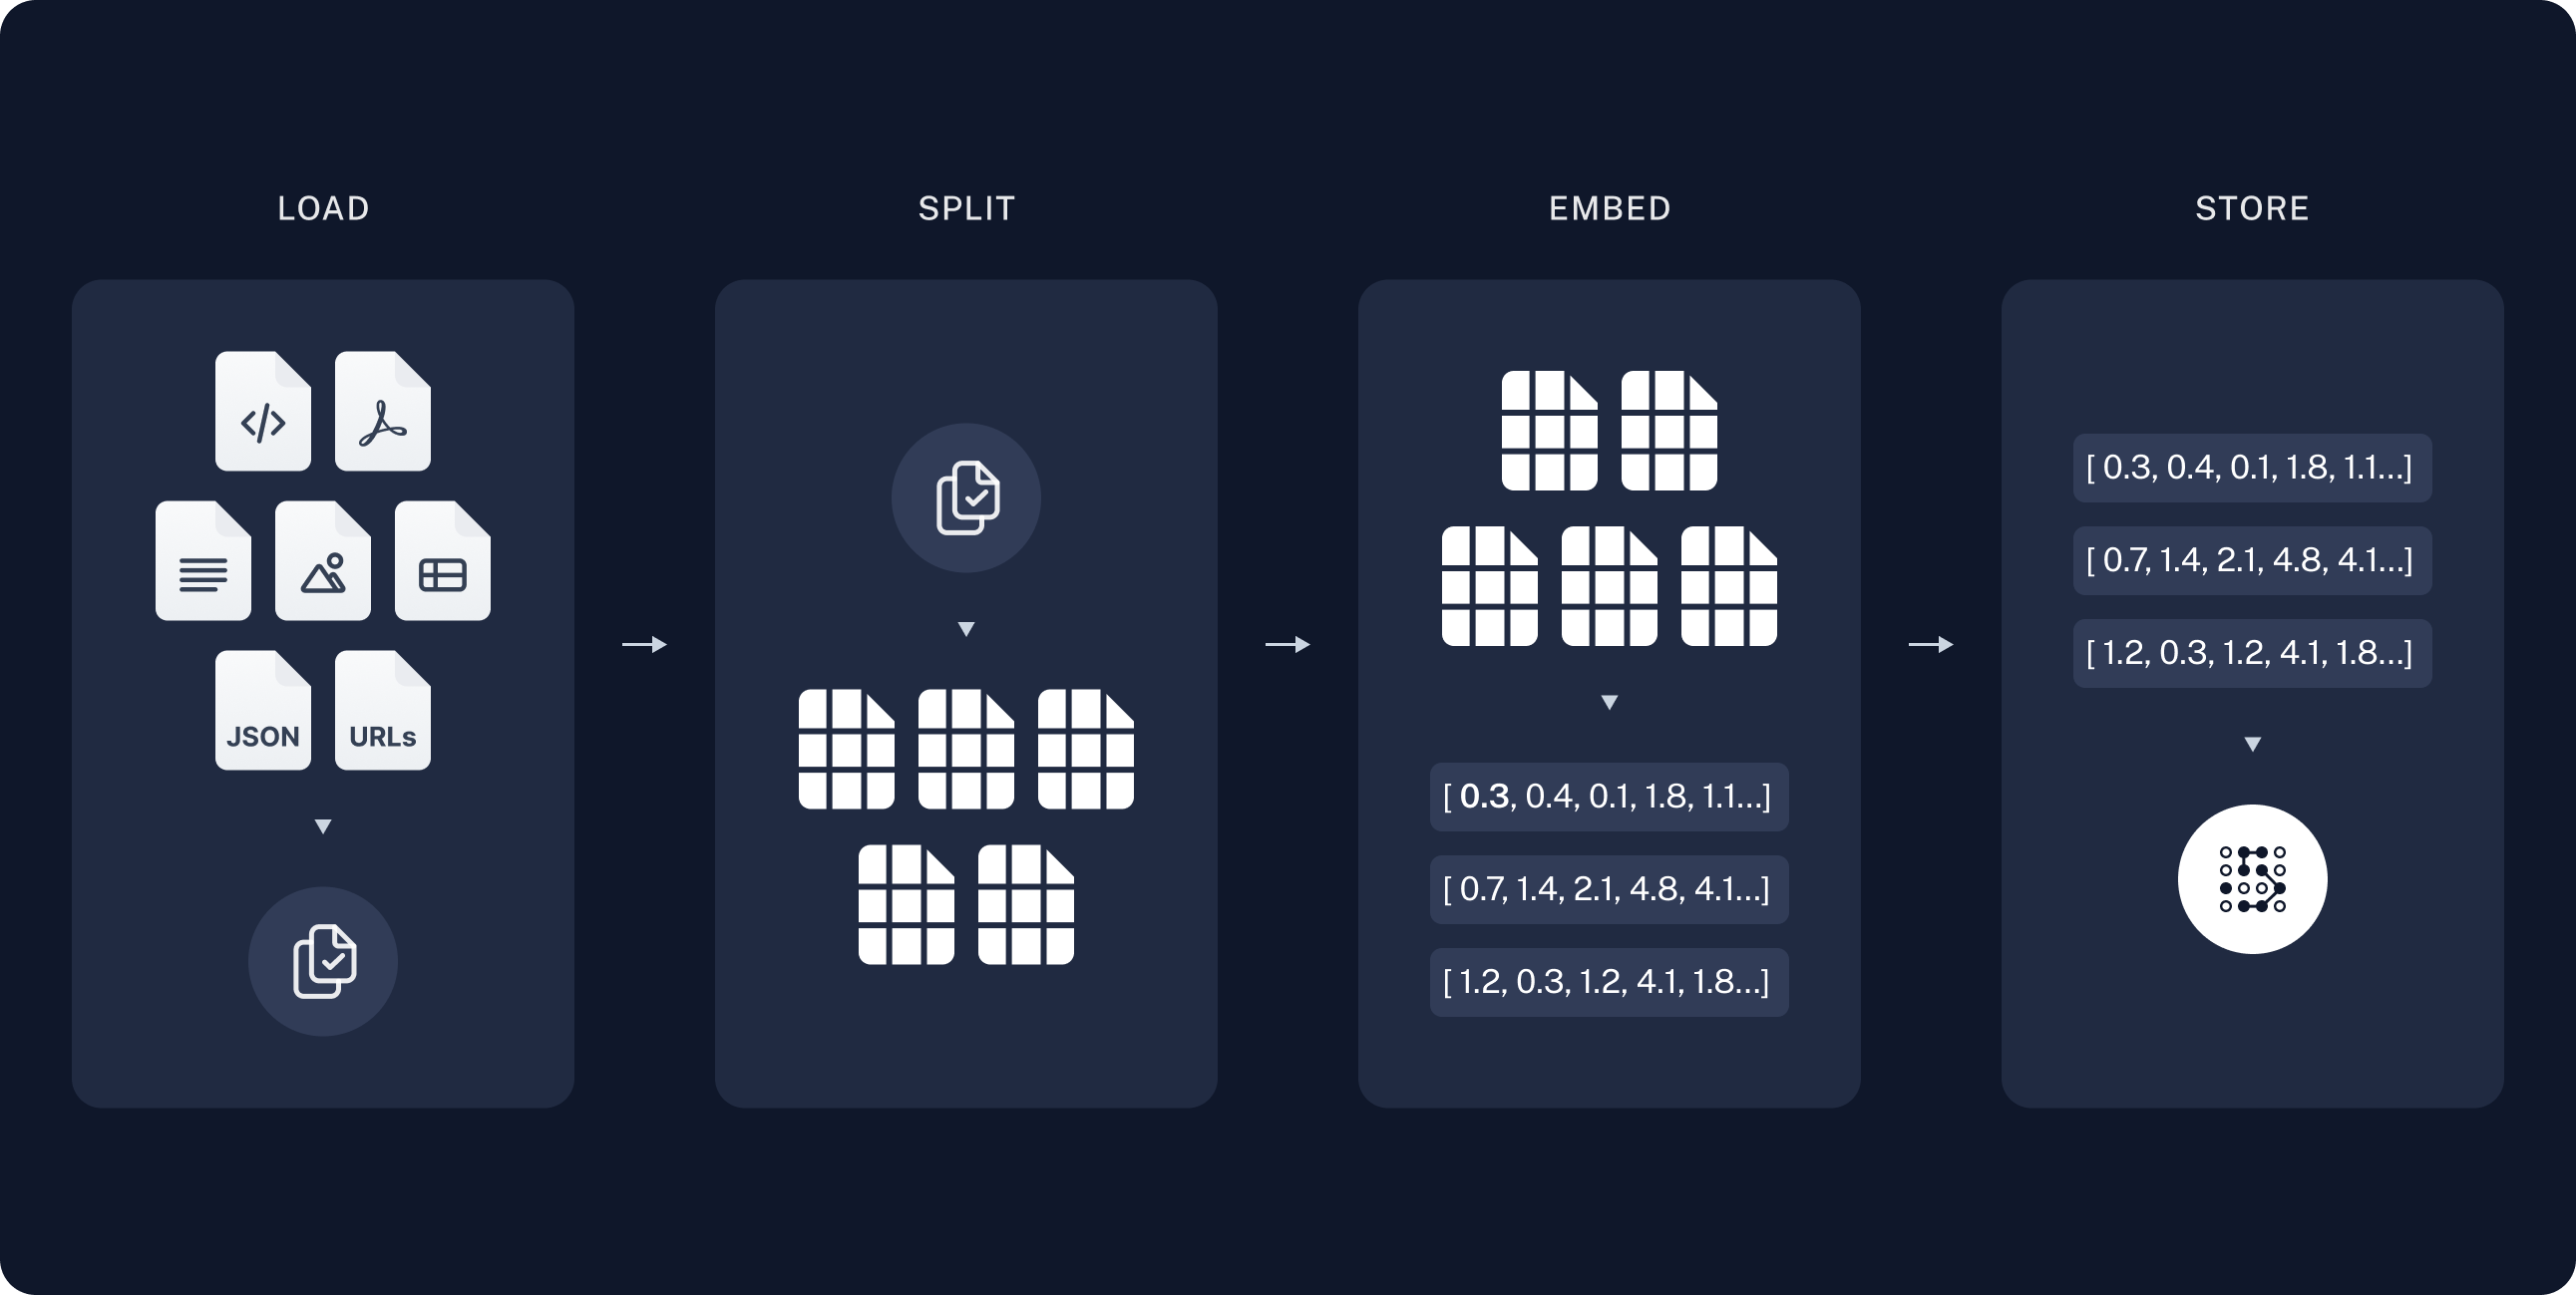

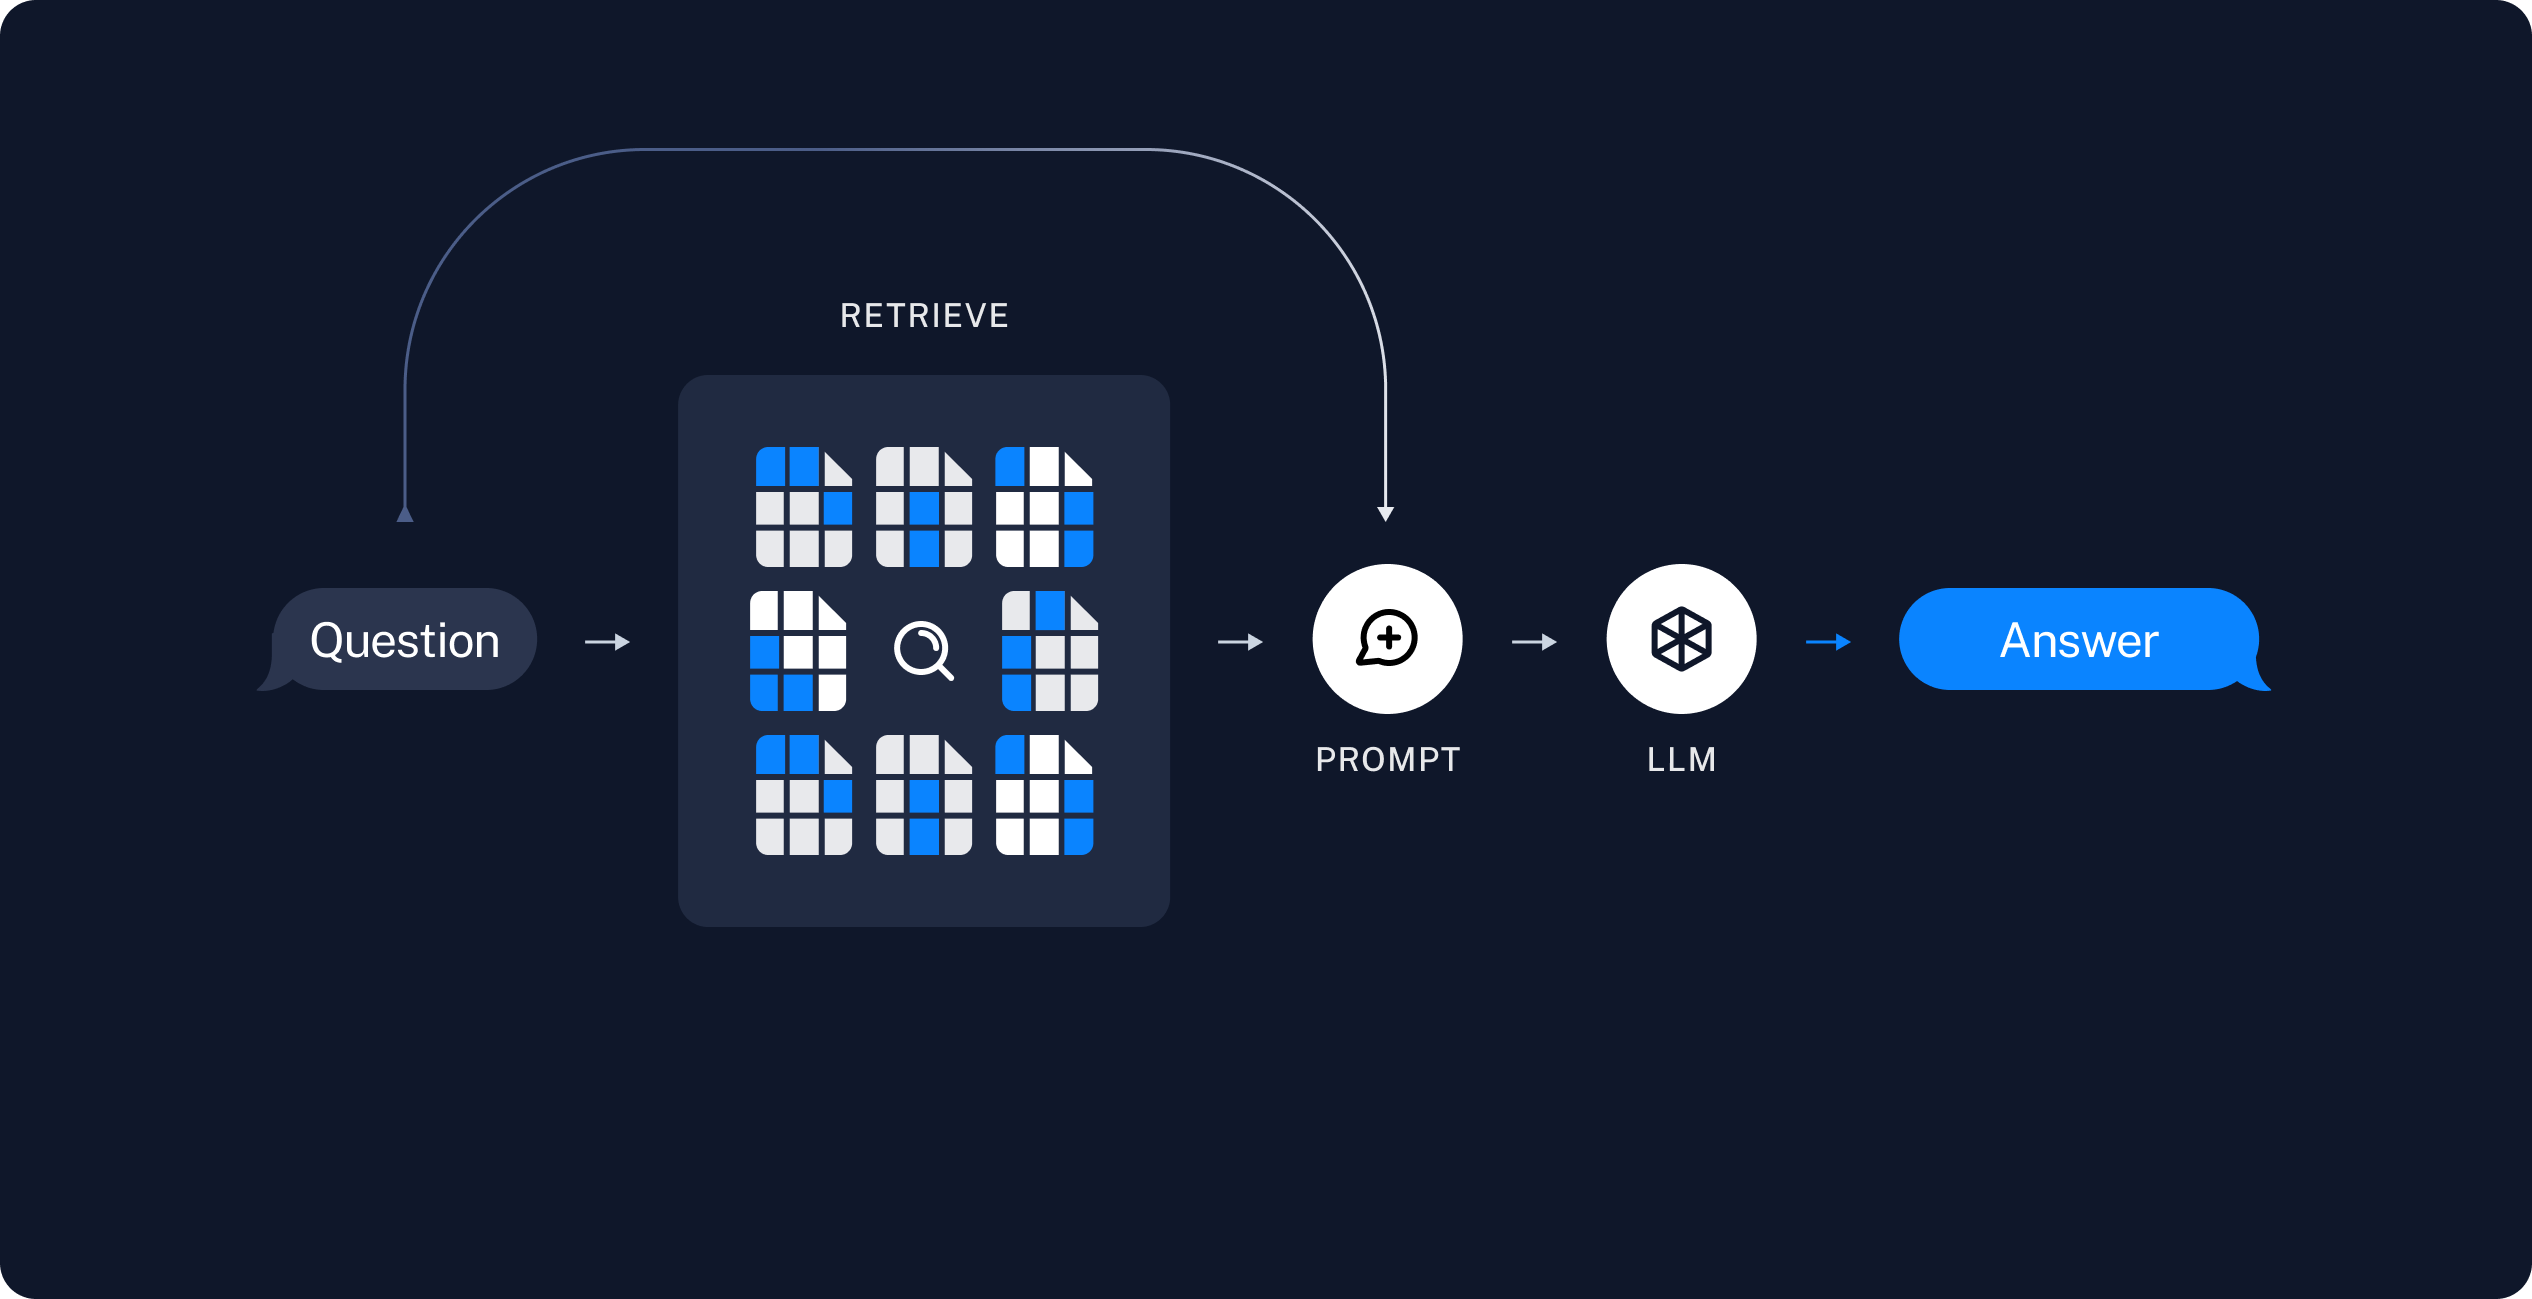

## Data Ingestion

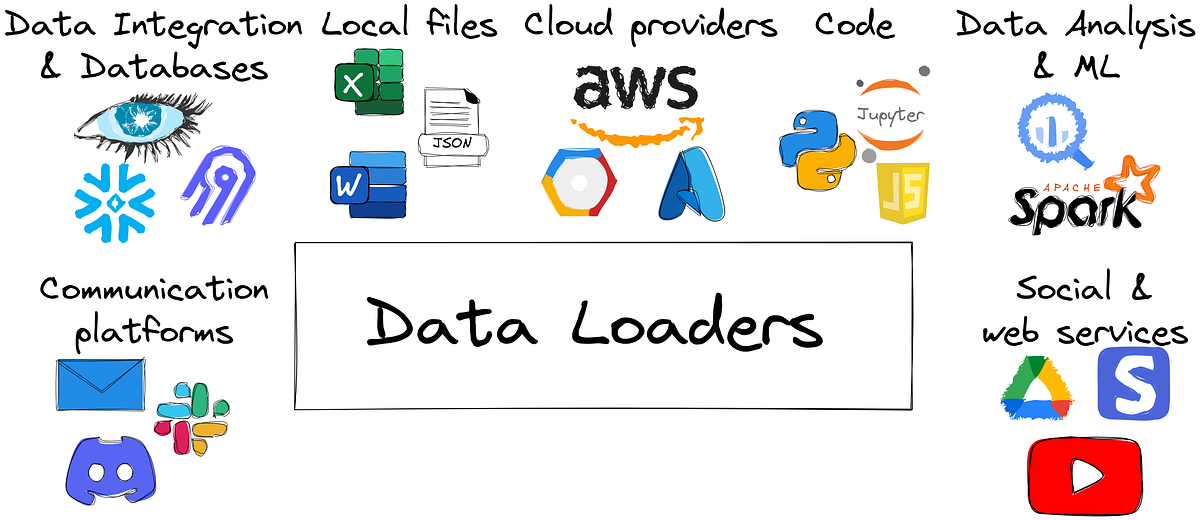

LINK to documentation : https://python.langchain.com/docs/integrations/document_loaders/

### TEXT LOADER



https://python.langchain.com/api_reference/community/document_loaders/langchain_community.document_loaders.text.TextLoader.html

In [ ]:
from langchain_community.document_loaders import TextLoader


loader = TextLoader("speech.txt")
loader

In [ ]:
text_documents=loader.load()
text_documents

[Document(metadata={'source': 'speech.txt'}, page_content='The world must be made safe for democracy. Its peace must be planted upon the tested foundations of political liberty. We have no selfish ends to serve. We desire no conquest, no dominion. We seek no indemnities for ourselves, no material compensation for the sacrifices we shall freely make. We are but one of the champions of the rights of mankind. We shall be satisfied when those rights have been made as secure as the faith and the freedom of nations can make them.\n\nJust because we fight without rancor and without selfish object, seeking nothing for ourselves but what we shall wish to share with all free peoples, we shall, I feel confident, conduct our operations as belligerents without passion and ourselves observe with proud punctilio the principles of right and of fair play we profess to be fighting for.\n\n…\n\nIt will be all the easier for us to conduct ourselves as belligerents in a high spirit of right and fairness be

### PDF lOADER



https://python.langchain.com/docs/how_to/document_loader_pdf/

In [ ]:
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader('attention.pdf')
docs = loader.load()
docs

[Document(metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2023-08-03T00:07:29+00:00', 'author': '', 'keywords': '', 'moddate': '2023-08-03T00:07:29+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'attention.pdf', 'total_pages': 15, 'page': 0, 'page_label': '1'}, page_content='Provided proper attribution is provided, Google hereby grants permission to\nreproduce the tables and figures in this paper solely for use in journalistic or\nscholarly works.\nAttention Is All You Need\nAshish Vaswani∗\nGoogle Brain\navaswani@google.com\nNoam Shazeer∗\nGoogle Brain\nnoam@google.com\nNiki Parmar∗\nGoogle Research\nnikip@google.com\nJakob Uszkoreit∗\nGoogle Research\nusz@google.com\nLlion Jones∗\nGoogle Research\nllion@google.com\nAidan N. Gomez∗ †\nUniversity of Toronto\naidan@cs.toronto.edu\nŁukasz Kaiser∗\nGoogle Brain\nlukaszk

In [ ]:
type(docs[0])

langchain_core.documents.base.Document

### WEB BASED LOADER



https://python.langchain.com/docs/integrations/document_loaders/web_base/

Load from one link

In [ ]:
from langchain_community.document_loaders import WebBaseLoader
import bs4

loader = WebBaseLoader(web_path=("https://lilianweng.github.io/posts/2023-06-23-agent/"))

loader.load()

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final resu

Load from multiple links use - WEB PATHS

In [ ]:
from langchain_community.document_loaders import WebBaseLoader
import bs4

loader = WebBaseLoader(web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/","https://www.python.org/doc/","https://www.ableton.com/en/products/live-lite/"))

loader.load()

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final resu

indexing on different paths

In [ ]:
loader.load()[0]

Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final resul

## Data Transaformation

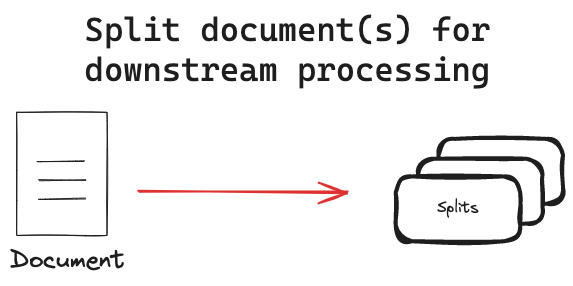

Link to Documentation : https://python.langchain.com/docs/concepts/text_splitters/

#### Text Splitting from Documents- RecursiveCharacter Text Splitters

Load the data

In [ ]:
from langchain_community.document_loaders import PyPDFLoader
loader = PyPDFLoader('attention.pdf')
docs = loader.load()
## number of pages
docs[0]

Document(metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2023-08-03T00:07:29+00:00', 'author': '', 'keywords': '', 'moddate': '2023-08-03T00:07:29+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'attention.pdf', 'total_pages': 15, 'page': 0, 'page_label': '1'}, page_content='Provided proper attribution is provided, Google hereby grants permission to\nreproduce the tables and figures in this paper solely for use in journalistic or\nscholarly works.\nAttention Is All You Need\nAshish Vaswani∗\nGoogle Brain\navaswani@google.com\nNoam Shazeer∗\nGoogle Brain\nnoam@google.com\nNiki Parmar∗\nGoogle Research\nnikip@google.com\nJakob Uszkoreit∗\nGoogle Research\nusz@google.com\nLlion Jones∗\nGoogle Research\nllion@google.com\nAidan N. Gomez∗ †\nUniversity of Toronto\naidan@cs.toronto.edu\nŁukasz Kaiser∗\nGoogle Brain\nlukaszka

Split by characters , meaning \n etc

exploring split documents

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=500 , chunk_overlap=50)
final_docs = text_splitter.split_documents(docs)
# no of splits
final_docs[4]

Document(metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2023-08-03T00:07:29+00:00', 'author': '', 'keywords': '', 'moddate': '2023-08-03T00:07:29+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'attention.pdf', 'total_pages': 15, 'page': 0, 'page_label': '1'}, page_content='the effort to evaluate this idea. Ashish, with Illia, designed and implemented the first Transformer models and\nhas been crucially involved in every aspect of this work. Noam proposed scaled dot-product attention, multi-head\nattention and the parameter-free position representation and became the other person involved in nearly every\ndetail. Niki designed, implemented, tuned and evaluated countless model variants in our original codebase and')

## Embeddding Techniques

Converting text into vectors

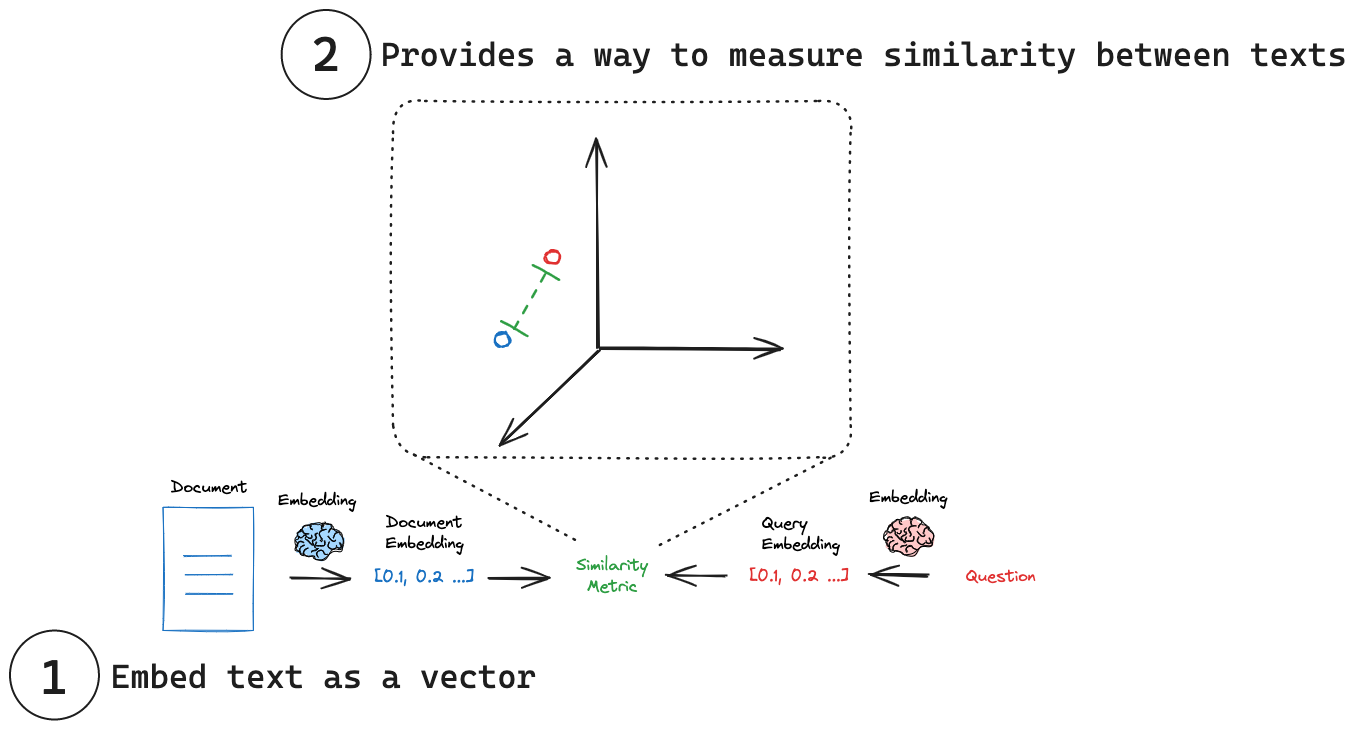

About Embeddings - https://python.langchain.com/docs/concepts/embedding_models/

Embedding Models - https://python.langchain.com/docs/integrations/text_embedding/

#### google gen ai embeddings



https://python.langchain.com/docs/integrations/text_embedding/google_generative_ai/


In [ ]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings

embeddings = GoogleGenerativeAIEmbeddings(model="models/embedding-001")
vector = embeddings.embed_query("hello, world!")
vector[:5]

[0.05636945366859436,
 0.004828543867915869,
 -0.07625909894704819,
 -0.023642510175704956,
 0.053293220698833466]

In [ ]:
## size of embedding

len(vector)

768

## Different Vector Stores

Import necesssary libraries

for the below process

Data Ingestion -> Data split -> Embedding the data -> Storing in vectordb and retrving the similar vector


why because we want to provide context to the model


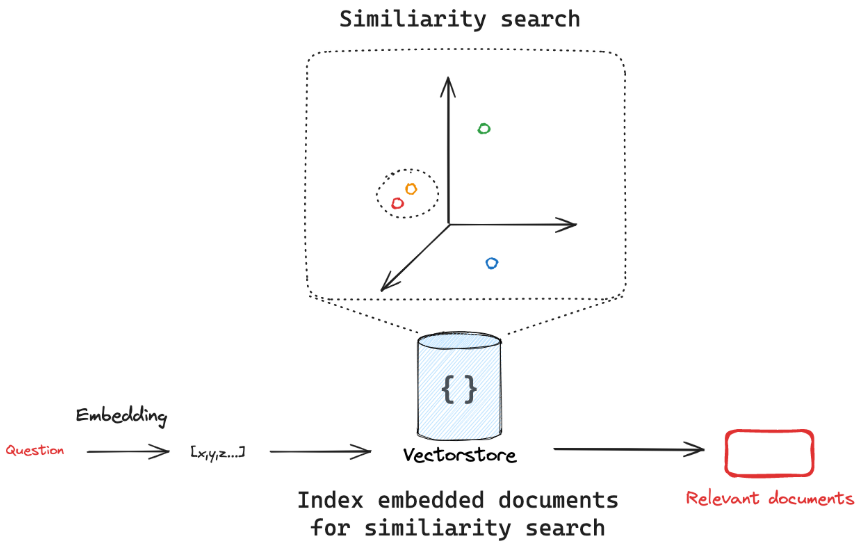




All langchain vector stores : https://python.langchain.com/docs/integrations/vectorstores/

### FAISS




Facebook AI Similarity Search (Faiss) is a library for efficient similarity search and clustering of dense vectors. It contains algorithms that search in sets of vectors of any size, up to ones that possibly do not fit in RAM. It also contains supporting code for evaluation and parameter tuning.

https://python.langchain.com/docs/integrations/vectorstores/faiss/

In [ ]:
from langchain_text_splitters import CharacterTextSplitter
from langchain_community.document_loaders import TextLoader
from langchain.vectorstores import FAISS
from langchain_google_genai import GoogleGenerativeAIEmbeddings


load data
and
split data

In [ ]:
loader = TextLoader("speech.txt")
documents = loader.load()
text_splitter = CharacterTextSplitter(chunk_size = 1000 , chunk_overlap = 50)
docs = text_splitter.split_documents(documents)

In [ ]:
docs[0].page_content

'The world must be made safe for democracy. Its peace must be planted upon the tested foundations of political liberty. We have no selfish ends to serve. We desire no conquest, no dominion. We seek no indemnities for ourselves, no material compensation for the sacrifices we shall freely make. We are but one of the champions of the rights of mankind. We shall be satisfied when those rights have been made as secure as the faith and the freedom of nations can make them.\n\nJust because we fight without rancor and without selfish object, seeking nothing for ourselves but what we shall wish to share with all free peoples, we shall, I feel confident, conduct our operations as belligerents without passion and ourselves observe with proud punctilio the principles of right and of fair play we profess to be fighting for.\n\n…'

In [ ]:
embeddings = GoogleGenerativeAIEmbeddings(model="models/embedding-001")

db = FAISS.from_documents(docs , embeddings)
db

querying

In [ ]:
query="How does the speaker describe the desired outcome of the war?"

In [ ]:
docs = db.similarity_search(query)
docs

[Document(id='0db48a59-f5e2-45a5-a709-59bc2d33eb1d', metadata={'source': 'speech.txt'}, page_content='The world must be made safe for democracy. Its peace must be planted upon the tested foundations of political liberty. We have no selfish ends to serve. We desire no conquest, no dominion. We seek no indemnities for ourselves, no material compensation for the sacrifices we shall freely make. We are but one of the champions of the rights of mankind. We shall be satisfied when those rights have been made as secure as the faith and the freedom of nations can make them.\n\nJust because we fight without rancor and without selfish object, seeking nothing for ourselves but what we shall wish to share with all free peoples, we shall, I feel confident, conduct our operations as belligerents without passion and ourselves observe with proud punctilio the principles of right and of fair play we profess to be fighting for.\n\n…'),
 Document(id='e6e20562-b9e2-42a4-bda2-b3415332c799', metadata={'sour

In [ ]:
docs[0].page_content

# retrieved the closest vector

'The world must be made safe for democracy. Its peace must be planted upon the tested foundations of political liberty. We have no selfish ends to serve. We desire no conquest, no dominion. We seek no indemnities for ourselves, no material compensation for the sacrifices we shall freely make. We are but one of the champions of the rights of mankind. We shall be satisfied when those rights have been made as secure as the faith and the freedom of nations can make them.\n\nJust because we fight without rancor and without selfish object, seeking nothing for ourselves but what we shall wish to share with all free peoples, we shall, I feel confident, conduct our operations as belligerents without passion and ourselves observe with proud punctilio the principles of right and of fair play we profess to be fighting for.\n\n…'

using vector db As a Retriever


We can also convert the vectorstore into a Retriever class. This allows us to easily use it in other LangChain methods, which largely work with retrievers

In [ ]:
retriever = db.as_retriever()
docs = retriever.invoke(query)
docs[0].page_content

## you can see same results

'The world must be made safe for democracy. Its peace must be planted upon the tested foundations of political liberty. We have no selfish ends to serve. We desire no conquest, no dominion. We seek no indemnities for ourselves, no material compensation for the sacrifices we shall freely make. We are but one of the champions of the rights of mankind. We shall be satisfied when those rights have been made as secure as the faith and the freedom of nations can make them.\n\nJust because we fight without rancor and without selfish object, seeking nothing for ourselves but what we shall wish to share with all free peoples, we shall, I feel confident, conduct our operations as belligerents without passion and ourselves observe with proud punctilio the principles of right and of fair play we profess to be fighting for.\n\n…'

Similarity Search with score


There are some FAISS specific methods. One of them is similarity_search_with_score, which allows you to return not only the documents but also the distance score of the query to them. The returned distance score is L2 distance. Therefore, a lower score is better.

In [ ]:
docs_and_score = db.similarity_search(query)
docs_and_score

[Document(id='0db48a59-f5e2-45a5-a709-59bc2d33eb1d', metadata={'source': 'speech.txt'}, page_content='The world must be made safe for democracy. Its peace must be planted upon the tested foundations of political liberty. We have no selfish ends to serve. We desire no conquest, no dominion. We seek no indemnities for ourselves, no material compensation for the sacrifices we shall freely make. We are but one of the champions of the rights of mankind. We shall be satisfied when those rights have been made as secure as the faith and the freedom of nations can make them.\n\nJust because we fight without rancor and without selfish object, seeking nothing for ourselves but what we shall wish to share with all free peoples, we shall, I feel confident, conduct our operations as belligerents without passion and ourselves observe with proud punctilio the principles of right and of fair play we profess to be fighting for.\n\n…'),
 Document(id='e6e20562-b9e2-42a4-bda2-b3415332c799', metadata={'sour

searching directly  by vector instead of text query

So convert the text into embedding first for that

In [ ]:
embedding_vec = embeddings.embed_query(query)
embedding_vec

[0.016372397541999817,
 -0.00508002657443285,
 -0.0498763807117939,
 -0.011054891161620617,
 0.047599758952856064,
 0.033864982426166534,
 0.02698804996907711,
 -0.004994174465537071,
 0.01530209556221962,
 0.09872470796108246,
 -0.04127160832285881,
 0.04337775707244873,
 -0.022796953096985817,
 0.01920197904109955,
 0.006095061078667641,
 -0.03943942114710808,
 0.004745278973132372,
 0.04806825518608093,
 0.04179033264517784,
 -0.030454102903604507,
 0.02033490315079689,
 0.018202101811766624,
 -0.017863070592284203,
 -0.0027552281972020864,
 0.025647884234786034,
 -0.05551186203956604,
 0.004828534089028835,
 -0.030810881406068802,
 -0.013428661040961742,
 0.009260470978915691,
 -0.061938848346471786,
 0.032866399735212326,
 -0.015740077942609787,
 0.02203313820064068,
 0.023636532947421074,
 -0.05419587343931198,
 0.017505791038274765,
 0.018594076856970787,
 -0.014981703832745552,
 0.03444404900074005,
 0.02467672899365425,
 -0.007832841947674751,
 -0.03153052553534508,
 0.0301278

In [ ]:
docs_score = db.similarity_search_by_vector(embedding_vec)
docs_score[0]
## most similar

Document(id='0db48a59-f5e2-45a5-a709-59bc2d33eb1d', metadata={'source': 'speech.txt'}, page_content='The world must be made safe for democracy. Its peace must be planted upon the tested foundations of political liberty. We have no selfish ends to serve. We desire no conquest, no dominion. We seek no indemnities for ourselves, no material compensation for the sacrifices we shall freely make. We are but one of the champions of the rights of mankind. We shall be satisfied when those rights have been made as secure as the faith and the freedom of nations can make them.\n\nJust because we fight without rancor and without selfish object, seeking nothing for ourselves but what we shall wish to share with all free peoples, we shall, I feel confident, conduct our operations as belligerents without passion and ourselves observe with proud punctilio the principles of right and of fair play we profess to be fighting for.\n\n…')

Saving and loading

In [ ]:
db.save_local("fiass_index_data")

In [ ]:
new_db = FAISS.load_local("fiass_index_data" , embeddings , allow_dangerous_deserialization=True)
docs = new_db.similarity_search(query)

In [ ]:
docs

[Document(id='0db48a59-f5e2-45a5-a709-59bc2d33eb1d', metadata={'source': 'speech.txt'}, page_content='The world must be made safe for democracy. Its peace must be planted upon the tested foundations of political liberty. We have no selfish ends to serve. We desire no conquest, no dominion. We seek no indemnities for ourselves, no material compensation for the sacrifices we shall freely make. We are but one of the champions of the rights of mankind. We shall be satisfied when those rights have been made as secure as the faith and the freedom of nations can make them.\n\nJust because we fight without rancor and without selfish object, seeking nothing for ourselves but what we shall wish to share with all free peoples, we shall, I feel confident, conduct our operations as belligerents without passion and ourselves observe with proud punctilio the principles of right and of fair play we profess to be fighting for.\n\n…'),
 Document(id='e6e20562-b9e2-42a4-bda2-b3415332c799', metadata={'sour

## Langchain and RAG EXPERIENCE

#### Langchain Expression Language (LECL)

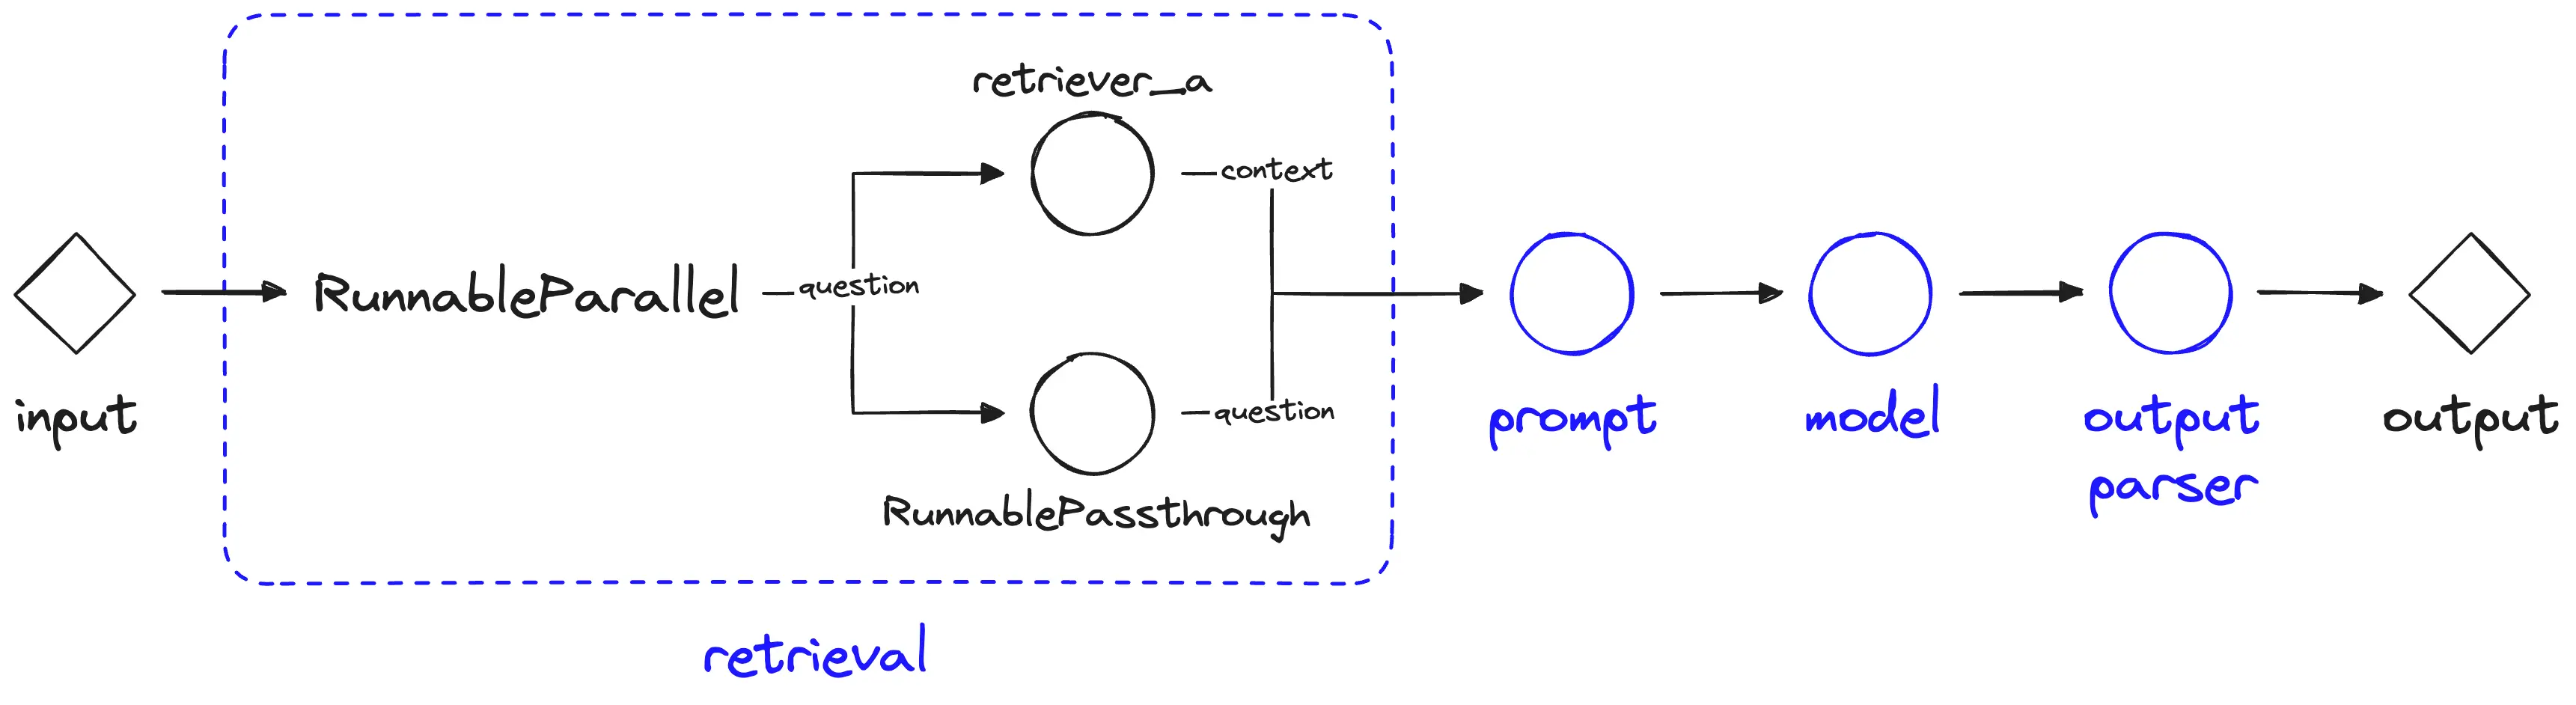

In [ ]:
import os
from langchain_groq import ChatGroq


Loading Groq Model

In [ ]:
groq_api_key = "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"

In [ ]:
model = ChatGroq(model="llama-3.1-8b-instant" , groq_api_key = groq_api_key)
print(model)

client=<groq.resources.chat.completions.Completions object at 0x79fa3bad7cd0> async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x79fa541e3790> model_name='llama-3.1-8b-instant' model_kwargs={} groq_api_key=SecretStr('**********')


Lets see our model , now you can see we can invoke the model directly

In [ ]:
model.invoke("Kaisa hai bhai , hindi aati hai tuje")

AIMessage(content='Main ek artificial intelligence (AI) hoon, aur main Hindi aur kai anya bhashaon mein baat kar sakta hoon. \n\nMain is tarah se kaam karta hoon: \n\n- Main sawal aur swikar kar sakta hoon. \n- Main jankari pradaan kar sakta hoon. \n- Main baatcheet kar sakta hoon. \n- Main kahani, gyaan, aur anya karyaon ko prabandhit kar sakta hoon.\n\nAap mujse kisi bhi cheez ki jankari lena chahte hain ya kuchh sawal poochhna chahte hain, toh main aapki madad kar sakta hoon.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 163, 'prompt_tokens': 48, 'total_tokens': 211, 'completion_time': 0.342207494, 'prompt_time': 0.003185109, 'queue_time': 0.551538113, 'total_time': 0.345392603}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_c523237e5d', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--61640878-5e38-4631-a7cb-c760652c606d-0', usage_metadata={'input_tokens': 48, 'output_tokens': 163, 'total_tokens': 

okay now lets make a list of messages using langchain core and lets give that to model instead of plain text

In [ ]:
from langchain_core.messages import HumanMessage , SystemMessage

messages = [
    SystemMessage(content = "Translate the following from Englist to Spanish"),
    HumanMessage(content= "Lets go visit a new resturant nearby")
]

result = model.invoke(messages)
result

AIMessage(content='Vámonos a visitar un nuevo restaurante cerca.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 52, 'total_tokens': 66, 'completion_time': 0.026830627, 'prompt_time': 0.004050958, 'queue_time': 0.21911015, 'total_time': 0.030881585}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_c523237e5d', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--5bc3db23-54bd-441e-9073-8a209b6a4f7f-0', usage_metadata={'input_tokens': 52, 'output_tokens': 14, 'total_tokens': 66})

We can see its working fine , and it gives out a AI message . to get the proper answer we will have to manually write like below

In [ ]:
result.content

'Vámonos a visitar un nuevo restaurante cerca.'

But we have a way to use a method and get such output without mentionion .content , we will use output parser , which cleans and structures our output like we want


https://python.langchain.com/docs/concepts/output_parsers/

So this parsers work is to invoke the result from the model

In [ ]:
from langchain_core.output_parsers import StrOutputParser

parser = StrOutputParser()

parser.invoke(result)

'Vámonos a visitar un nuevo restaurante cerca.'

lets use LECL and chain it , since model ---> result --> parser --> final output

and see it works perfectly fine

In [ ]:
chain = model|parser
chain.invoke(messages)

'Vamos a visitar un nuevo restaurante cerca.'

Now dont you think manually writing system and human message can be a little boring since we are hardcoding / typing it , dont you think it should be dynamic where the prompts and the outputs will change according to user input ,

thats where prompt template comes in , where we can put placeholders which can change

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

generic_template = "Translate the following into {language}"

prompt = ChatPromptTemplate.from_messages(
    [
        ("system",generic_template),
        ("user","{text}")
    ]
)

See now we can change as many langauges we want to and no manualy writting it

In [ ]:
result = prompt.invoke({"language":"Spanish" , "text" : "Its too cold here"})


In [ ]:
result.to_messages()

[SystemMessage(content='Translate the following into Spanish', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='Its too cold here', additional_kwargs={}, response_metadata={})]

now when we check this result and pass it to through messages , we can see its getting converted into system and human message automatically , which is what we were doing earlier ,

this is a better method and more control over the output ,

PROMPT TEMPLATE

now lets chain this as well

In [ ]:
chain = prompt|model|parser
chain.invoke({"language":"Spanish" , "text":"Bonjour"})

'La traducción de "Bonjour" al español es "Buenos días". \n\nSi deseas una traducción más general que incluya todas las horas del día, puedes utilizar "Hola" o "Hola, ¿cómo estás?"'

SEE so we saw how lecl works , its a way of chaining langchain componets together

COOOL

#### Exploring COMPLETE RAG FLOW , RIGHT FROM COLLECTING DATA TO gining context to chain to response !!!

Environment setup

libraries import

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI , GoogleGenerativeAIEmbeddings
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_core.prompts import ChatPromptTemplate
from langchain.vectorstores import FAISS
from langchain.chains.combine_documents import create_stuff_documents_chain
from langchain.chains import create_retrieval_chain


Data Ingestion

In [ ]:
loader=WebBaseLoader("https://python.langchain.com/docs/introduction/")
print(loader)
docs = loader.load()
print(docs)

[Document(metadata={'source': 'https://python.langchain.com/docs/introduction/', 'title': 'Introduction | \uf8ffü¶úÔ∏è\uf8ffüîó LangChain', 'description': 'LangChain is a framework for developing applications powered by large language models (LLMs).', 'language': 'en'}, page_content='\n\n\n\n\nIntroduction | \uf8ffü¶úÔ∏è\uf8ffüîó LangChain\n\n\n\n\n\n\n\n\nSkip to main contentOur Building Ambient Agents with LangGraph course is now available on LangChain Academy!IntegrationsAPI ReferenceMoreContributingPeopleError referenceLangSmithLangGraphLangChain HubLangChain JS/TSv0.3v0.3v0.2v0.1\uf8ffüí¨SearchIntroductionTutorialsBuild a Question Answering application over a Graph DatabaseTutorialsBuild a simple LLM application with chat models and prompt templatesBuild a ChatbotBuild a Retrieval Augmented Generation (RAG) App: Part 2Build an Extraction ChainBuild an AgentTaggingBuild a Retrieval Augmented Generation (RAG) App: Part 1Build a semantic search engineBuild a Question/Answering system

Data Splits

In [ ]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=200)
documents = text_splitter.split_documents(docs)
documents[:3]

[Document(metadata={'source': 'https://python.langchain.com/docs/introduction/', 'title': 'Introduction | \uf8ffü¶úÔ∏è\uf8ffüîó LangChain', 'description': 'LangChain is a framework for developing applications powered by large language models (LLMs).', 'language': 'en'}, page_content='Introduction | \uf8ffü¶úÔ∏è\uf8ffüîó LangChain'),
 Document(metadata={'source': 'https://python.langchain.com/docs/introduction/', 'title': 'Introduction | \uf8ffü¶úÔ∏è\uf8ffüîó LangChain', 'description': 'LangChain is a framework for developing applications powered by large language models (LLMs).', 'language': 'en'}, page_content='Skip to main contentOur Building Ambient Agents with LangGraph course is now available on LangChain Academy!IntegrationsAPI ReferenceMoreContributingPeopleError referenceLangSmithLangGraphLangChain HubLangChain JS/TSv0.3v0.3v0.2v0.1\uf8ffüí¨SearchIntroductionTutorialsBuild a Question Answering application over a Graph DatabaseTutorialsBuild a simple LLM application with chat mo

In [ ]:
documents[10].page_content

'LangChain is a framework for developing applications powered by large language models (LLMs).\nLangChain simplifies every stage of the LLM application lifecycle:'

Initialize google Embeddings

In [ ]:
embeddings = GoogleGenerativeAIEmbeddings(model="models/embedding-001")

Store splitted data into vector db

In [ ]:
vectordb = FAISS.from_documents(documents,embeddings)

In [ ]:
print(type(vectordb))

<class 'langchain_community.vectorstores.faiss.FAISS'>


Try to query/retrive similar context from vector db according to given input

In [ ]:
query = "What is Architecture of langchain "
result = vectordb.similarity_search(query)
result[0].page_content

'Introduction | \uf8ffü¶úÔ∏è\uf8ffüîó LangChain'

LLM model Initialize

In [ ]:
groq_api_key = "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"

model = ChatGroq(model="llama-3.1-8b-instant" , groq_api_key = groq_api_key)
print(model)

client=<groq.resources.chat.completions.Completions object at 0x79fa3d8bfe10> async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x79fa44a22ed0> model_name='llama-3.1-8b-instant' model_kwargs={} groq_api_key=SecretStr('**********')


lets create a document chain and a prompt template

In [ ]:
prompt = ChatPromptTemplate.from_template(
    """
    Answer the question based only on the provided context :
    <context>
    {context}
    </context>

    """
)

doc_chain =create_stuff_documents_chain(model , prompt)
doc_chain

RunnableBinding(bound=RunnableBinding(bound=RunnableAssign(mapper={
  context: RunnableLambda(format_docs)
}), kwargs={}, config={'run_name': 'format_inputs'}, config_factories=[])
| ChatPromptTemplate(input_variables=['context'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context'], input_types={}, partial_variables={}, template='\n    Answer the question based only on the provided context :\n    <context>\n    {context}\n    </context>\n\n    '), additional_kwargs={})])
| ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x79fa3bad7cd0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x79fa541e3790>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'))
| StrOutputParser(), kwargs={}, config={'run_name': 'stuff_documents_chain'}, config_factories=[])

Lets see a manual approach of llm giving some output by some manual context which we will be providing not the vector db and how it responsds


so we are testing llm how it responds given some context

In [ ]:
from langchain_core.documents import Document
# some library to convert the text into document
# because llm or the chain or the invoke methods takes only documents as input

doc_chain.invoke({
    "input":"What is the best and safe dose range for lsd",
    "context":[Document(page_content="""
                        LSD is an extraordinarily potent substance,[8][43][13][44] and is one of the most potent psychoactive drugs known.[13][44] This means that it produces its pharmacological effects at very small doses, with its dose range measured in micrograms (μg); that is, millionths of a gram.[8][13] Noticeable effects can occur with doses of LSD as low as 20 μg, which is around 1/200th the mass of a grain of sand.[8][43][13][21] LSD is approximately 200 times as potent as psilocybin and 5,000 times as potent as mescaline, meaning that it produces effects of similar magnitude at 1/200 and 1/5,000 times the respective doses.[8][43][45]

The usual dose range of LSD for psychedelic effects is 20 to 200 μg.[8][43] The typical intermediate and "good effect" dose for a psychedelic experience is 100 μg (range 75–150 μg, while 20 to 50 μg is a low or "minidose" and 200 μg is a high or ego-dissolution dose.[8][43][7] A dose range as wide as 10 to 400 μg has been reported.[46] LSD may also be used in microdosing.[47] In this context, it may be used at subthreshold or microdoses of less than 10 μg
                        """)]
})


'Based on the provided context, here are the answers to the questions:\n\n1. How potent is LSD compared to psilocybin? \n   LSD is approximately 200 times as potent as psilocybin.\n\n2. How potent is LSD compared to mescaline? \n   LSD is approximately 5,000 times as potent as mescaline.\n\n3. What is the usual dose range of LSD for psychedelic effects? \n   The usual dose range of LSD for psychedelic effects is 20 to 200 μg.\n\n4. What is the typical intermediate and "good effect" dose for a psychedelic experience? \n   The typical intermediate and "good effect" dose for a psychedelic experience is 100 μg (range 75–150 μg).\n\n5. What dose range is considered a low or "minidose"? \n   A dose range of 20 to 50 μg is a low or "minidose".\n\n6. What dose range is considered a high or ego-dissolution dose? \n   200 μg is a high or ego-dissolution dose.\n\n7. What is the dose range for microdosing? \n   In the context of microdosing, LSD may be used at subthreshold or microdoses of less th


and the answer is correct as weell

It is doing good with manual context , now lets give dynamic context from vector db and get better results

However, we want the documents to first come from the retriever we just set up. That way, we can use the retriever to dynamically select the most relevant documents and pass those in for a given question.

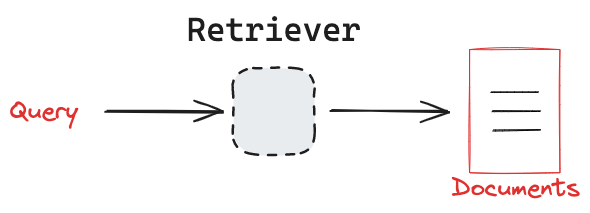

In [ ]:
### Input--->Retriever--->vectorstoredb

vectordb

So lets create a retriever chain

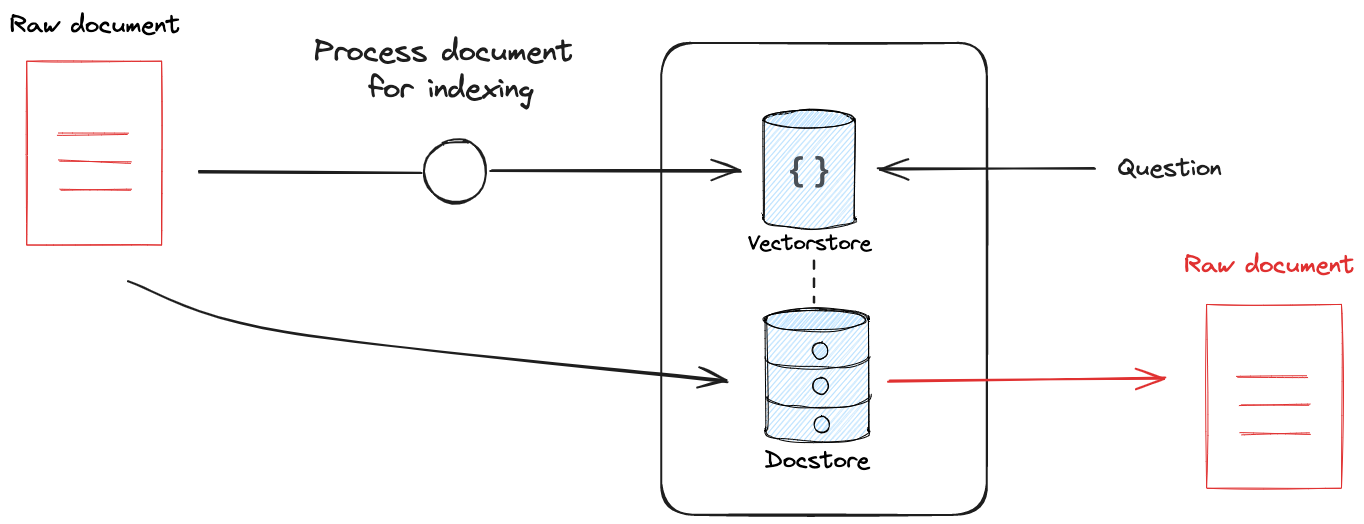

In [ ]:
retriever = vectordb.as_retriever()
from langchain.chains import create_retrieval_chain
retrieval_chain = create_retrieval_chain(retriever , doc_chain)
retrieval_chain

RunnableBinding(bound=RunnableAssign(mapper={
  context: RunnableBinding(bound=RunnableLambda(lambda x: x['input'])
           | VectorStoreRetriever(tags=['FAISS', 'GoogleGenerativeAIEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x79fa542fa350>, search_kwargs={}), kwargs={}, config={'run_name': 'retrieve_documents'}, config_factories=[])
})
| RunnableAssign(mapper={
    answer: RunnableBinding(bound=RunnableBinding(bound=RunnableAssign(mapper={
              context: RunnableLambda(format_docs)
            }), kwargs={}, config={'run_name': 'format_inputs'}, config_factories=[])
            | ChatPromptTemplate(input_variables=['context'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context'], input_types={}, partial_variables={}, template='\n    Answer the question based only on the provided context :\n    <context>\n    {context}\n    </context>\n\n    '), additional_kwargs={})

Now everything is set up

Lets give question to llm and get response with contextual understanding with respect to website

In [ ]:
response = retrieval_chain.invoke({"input":"What are Langchain"})
response['answer']

"Based on the provided context, it appears that the question is not explicitly stated. However, I can provide information on the following topics that are relevant to the context:\n\n1. What is LangChain?\nLangChain is a framework for developing applications powered by large language models (LLMs).\n\n2. What does LangChain simplify?\nLangChain simplifies every stage of the LLM application lifecycle.\n\n3. What are the versions of LangChain?\nThe versions mentioned are v0.3 and v0.2, along with Pydantic compatibility and migration guides for various previous versions.\n\n4. What are the resources provided by LangChain for security?\nRead up on security best practices to make sure you're developing safely with LangChain.\n\n5. What are the contributing guidelines for LangChain?\nCheck out the developer's guide for guidelines on contributing and help getting your dev environment set up.\n\n6. What are the LangChain ecosystem components?\nLangsmith and Langgraph are the ecosystem componen

In [ ]:
response

{'input': 'What are Langchain',
 'context': [Document(id='f8ca4e53-74b1-4f46-8361-21271b63970a', metadata={'source': 'https://python.langchain.com/docs/introduction/', 'title': 'Introduction | \uf8ffü¶úÔ∏è\uf8ffüîó LangChain', 'description': 'LangChain is a framework for developing applications powered by large language models (LLMs).', 'language': 'en'}, page_content='Introduction | \uf8ffü¶úÔ∏è\uf8ffüîó LangChain'),
  Document(id='8486974a-c49c-4e97-820d-58f89fc9f374', metadata={'source': 'https://python.langchain.com/docs/introduction/', 'title': 'Introduction | \uf8ffü¶úÔ∏è\uf8ffüîó LangChain', 'description': 'LangChain is a framework for developing applications powered by large language models (LLMs).', 'language': 'en'}, page_content='LangChain is a framework for developing applications powered by large language models (LLMs).\nLangChain simplifies every stage of the LLM application lifecycle:'),
  Document(id='fd183a75-449c-4709-b02f-85f2dadb2800', metadata={'source': 'https://p

In [ ]:
response['context']

[Document(id='f8ca4e53-74b1-4f46-8361-21271b63970a', metadata={'source': 'https://python.langchain.com/docs/introduction/', 'title': 'Introduction | \uf8ffü¶úÔ∏è\uf8ffüîó LangChain', 'description': 'LangChain is a framework for developing applications powered by large language models (LLMs).', 'language': 'en'}, page_content='Introduction | \uf8ffü¶úÔ∏è\uf8ffüîó LangChain'),
 Document(id='8486974a-c49c-4e97-820d-58f89fc9f374', metadata={'source': 'https://python.langchain.com/docs/introduction/', 'title': 'Introduction | \uf8ffü¶úÔ∏è\uf8ffüîó LangChain', 'description': 'LangChain is a framework for developing applications powered by large language models (LLMs).', 'language': 'en'}, page_content='LangChain is a framework for developing applications powered by large language models (LLMs).\nLangChain simplifies every stage of the LLM application lifecycle:'),
 Document(id='fd183a75-449c-4709-b02f-85f2dadb2800', metadata={'source': 'https://python.langchain.com/docs/introduction/', 'titl

In [ ]:
response = retrieval_chain.invoke({"input":"What are Embedding models "})
response['answer']


'Based on the provided context, it seems that LangChain is a framework for developing applications powered by large language models (LLMs). The context also lists various tutorials and guides on how to use LangChain, including topics such as:\n\n- Dispatching custom callback events\n- Passing callbacks at runtime\n- Caching chat model responses\n- Handling rate limits\n- Initializing models in one line\n- Tracking token usage\n- Adding tools to chatbots\n- Splitting code\n- Retrieval with contextual compression\n- Converting Runnables to Tools\n- Creating custom callback handlers\n- Creating custom chat model classes\n- Creating custom LLM classes\n- Creating custom retrievers\n- Debugging LLM apps\n- Loading various file types (CSVs, documents, HTML, JSON, Markdown, Microsoft Office files, PDFs, web pages)\n- Combining results from multiple retrievers\n- Selecting examples from LangSmith datasets\n- Selecting examples by length, MMR, or n-gram.'